1. What is Anomaly Detection? Explain its types (point, contextual, and
collective anomalies) with examples.

**Anomaly Detection** is a technique in data analysis and machine learning used to identify unusual patterns or observations that do not follow expected behavior (called anomalies or outliers).

### Types of Anomalies:

1. **Point Anomaly (Global Anomaly)**
   A single data point that is very different from the rest.
   **Example:** In bank transactions, a ₹1,00,000 withdrawal when a user usually withdraws ₹2,000.

2. **Contextual Anomaly (Conditional Anomaly)**
   A data point that is abnormal in a specific context (like time or location).
   **Example:** High electricity usage at midnight (unusual at that time, but normal during daytime).

3. **Collective Anomaly**
   A group of data points that together behave abnormally, even if individual points seem normal.
   **Example:** A sudden spike pattern in network traffic indicating a cyber attack.


2. Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of
their approach and suitable use cases.

Here’s a **short comparison**:

### 1. Isolation Forest

* **Approach:** Based on Machine Learning; isolates anomalies using random trees (anomalies are easier to isolate).
* **Use Case:** High-dimensional data, large datasets (e.g., fraud detection).

### 2. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

* **Approach:** Clustering method; points in low-density regions are treated as outliers.
* **Use Case:** Spatial data, clusters of arbitrary shape (e.g., geographic or sensor data).

### 3. Local Outlier Factor (LOF)

* **Approach:** Compares local density of a point with its neighbors; lower density = anomaly.
* **Use Case:** Detecting local anomalies where data density varies (e.g., intrusion detection).


3. What are the key components of a Time Series? Explain each with one
example.

A **Time Series** is a sequence of data points collected over time. Its key components are:

### 1. Trend

The long-term upward or downward movement in data.
**Example:** Increasing online sales over several years.

### 2. Seasonality

Regular, repeating patterns over fixed periods (daily, monthly, yearly).
**Example:** Ice cream sales increasing every summer.

### 3. Cyclical Variation

Fluctuations over longer, irregular periods (not fixed like seasonality).
**Example:** Economic growth and recession cycles.

### 4. Irregular (Random) Component

Unpredictable, random variations in data.
**Example:** Sudden drop in sales due to a natural disaster.


4. Define Stationary in time series. How can you test and transform a
non-stationary series into a stationary one.

### **Stationary Time Series**

A time series is **stationary** if its statistical properties (mean, variance, autocorrelation) remain **constant over time**.

---

### **How to Test Stationarity**

* **Visual check:** Plot the series (look for constant mean & variance)
* **Statistical tests:**

  * Augmented Dickey-Fuller Test (ADF) → checks presence of unit root
  * KPSS Test → checks stationarity directly

---

### **How to Transform Non-Stationary → Stationary**

* **Differencing:** Subtract previous value (removes trend)
* **Log / Square root transform:** Stabilizes variance
* **Detrending:** Remove trend component
* **Seasonal differencing:** Remove seasonal effects



5. Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in
terms of structure and application.

Here’s a **short comparison** of common time series models:

---

### **1. AR (AutoRegressive)**

* **Structure:** Depends on past values
  ( Y_t = c + \phi_1 Y_{t-1} + \dots )
* **Use Case:** When current value is influenced by its previous values (e.g., stock prices).

---

### **2. MA (Moving Average)**

* **Structure:** Depends on past errors (noise terms)
  ( Y_t = c + \theta_1 e_{t-1} + \dots )
* **Use Case:** When random shocks affect the series (e.g., sudden demand changes).

---

### **3. ARIMA (AutoRegressive Integrated Moving Average)**

* **Structure:** Combines AR + MA + differencing (I)
* **Use Case:** Non-stationary data made stationary using differencing.

---

### **4. SARIMA (Seasonal ARIMA)**

* **Structure:** ARIMA + seasonal components (P, D, Q, s)
* **Use Case:** Data with seasonality (e.g., monthly sales patterns).

---

### **5. SARIMAX (Seasonal ARIMA with Exogenous variables)**

* **Structure:** SARIMA + external variables (X)
* **Use Case:** When outside factors influence data (e.g., sales affected by ads, weather).



/tmp/ipykernel_5141/623837875.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = pd.Series(data, index=pd.date_range(start='1949-01', periods=len(data), freq='M'))


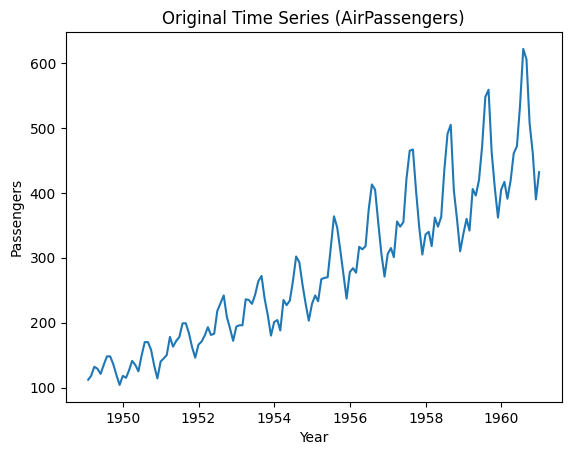

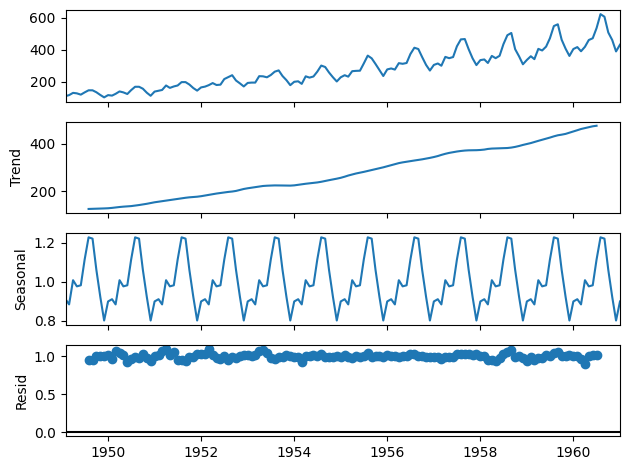

In [1]:
#  Load a time series dataset (e.g., AirPassengers), plot the original series,and decompose it into trend, seasonality, and residual components.

# Import libraries
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# AirPassengers dataset
data = [112,118,132,129,121,135,148,148,136,119,104,118,
115,126,141,135,125,149,170,170,158,133,114,140,
145,150,178,163,172,178,199,199,184,162,146,166,
171,180,193,181,183,218,230,242,209,191,172,194,
196,196,236,235,229,243,264,272,237,211,180,201,
204,188,235,227,234,264,302,293,259,229,203,229,
242,233,267,269,270,315,364,347,312,274,237,278,
284,277,317,313,318,374,413,405,355,306,271,306,
315,301,356,348,355,422,465,467,404,347,305,336,
340,318,362,348,363,435,491,505,404,359,310,337,
360,342,406,396,420,472,548,559,463,407,362,405,
417,391,419,461,472,535,622,606,508,461,390,432]

# Create time series
ts = pd.Series(data, index=pd.date_range(start='1949-01', periods=len(data), freq='M'))

# Plot original series
plt.figure()
plt.plot(ts)
plt.title("Original Time Series (AirPassengers)")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()

# Decompose the series
decomposition = seasonal_decompose(ts, model='multiplicative')

# Plot decomposition
decomposition.plot()
plt.show()


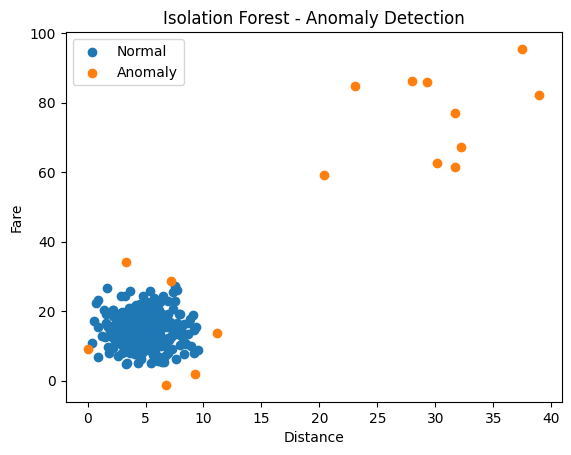

In [2]:
# Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot.

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Create synthetic NYC Taxi-like dataset
np.random.seed(42)
n = 300

fare = np.random.normal(15, 5, n)          # fare amount
distance = np.random.normal(5, 2, n)       # trip distance

# Add anomalies
fare_outliers = np.random.uniform(50, 100, 10)
distance_outliers = np.random.uniform(20, 40, 10)

fare = np.concatenate([fare, fare_outliers])
distance = np.concatenate([distance, distance_outliers])

# Create DataFrame
df = pd.DataFrame({'fare': fare, 'distance': distance})

# Apply Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
df['anomaly'] = model.fit_predict(df)

# anomaly = -1 (outlier), 1 (normal)
anomalies = df[df['anomaly'] == -1]
normal = df[df['anomaly'] == 1]

# Plot
plt.figure()
plt.scatter(normal['distance'], normal['fare'], label='Normal')
plt.scatter(anomalies['distance'], anomalies['fare'], label='Anomaly')
plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Isolation Forest - Anomaly Detection")
plt.legend()
plt.show()

/tmp/ipykernel_5141/3239137527.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ts = pd.Series(data, index=pd.date_range(start='1949-01', periods=len(data), freq='M'))


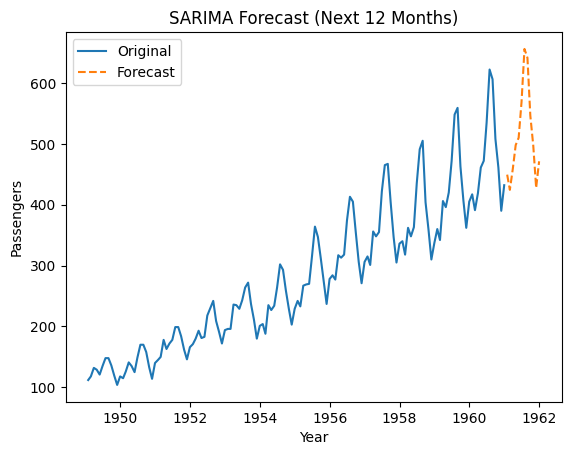

In [3]:
# Train a SARIMA model on the monthly airline passengers dataset.Forecast the next 12 months and visualize the results.

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# AirPassengers dataset
data = [112,118,132,129,121,135,148,148,136,119,104,118,
115,126,141,135,125,149,170,170,158,133,114,140,
145,150,178,163,172,178,199,199,184,162,146,166,
171,180,193,181,183,218,230,242,209,191,172,194,
196,196,236,235,229,243,264,272,237,211,180,201,
204,188,235,227,234,264,302,293,259,229,203,229,
242,233,267,269,270,315,364,347,312,274,237,278,
284,277,317,313,318,374,413,405,355,306,271,306,
315,301,356,348,355,422,465,467,404,347,305,336,
340,318,362,348,363,435,491,505,404,359,310,337,
360,342,406,396,420,472,548,559,463,407,362,405,
417,391,419,461,472,535,622,606,508,461,390,432]

# Create time series
ts = pd.Series(data, index=pd.date_range(start='1949-01', periods=len(data), freq='M'))

# Train SARIMA model (example parameters)
model = SARIMAX(ts, order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit()

# Forecast next 12 months
forecast = results.forecast(steps=12)

# Plot results
plt.figure()
plt.plot(ts, label='Original')
plt.plot(forecast, label='Forecast', linestyle='--')
plt.title("SARIMA Forecast (Next 12 Months)")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.legend()
plt.show()

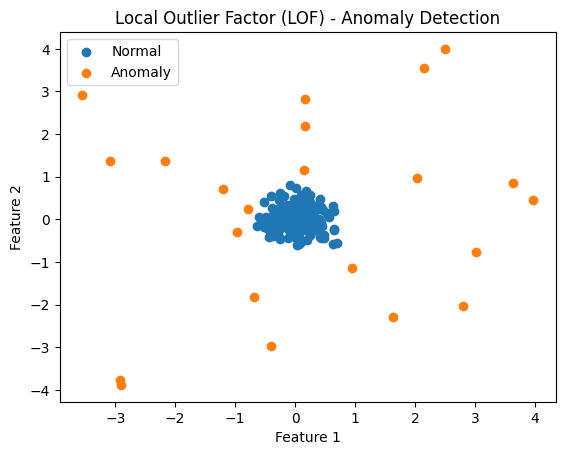

In [4]:
# Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib.

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Create synthetic dataset
np.random.seed(42)
X_normal = 0.3 * np.random.randn(200, 2)
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))

X = np.r_[X_normal, X_outliers]

# Apply LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
y_pred = lof.fit_predict(X)

# Separate normal and anomalies
normal = X[y_pred == 1]
anomalies = X[y_pred == -1]

# Plot
plt.figure()
plt.scatter(normal[:, 0], normal[:, 1], label="Normal")
plt.scatter(anomalies[:, 0], anomalies[:, 1], label="Anomaly")
plt.title("Local Outlier Factor (LOF) - Anomaly Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()


/tmp/ipykernel_5141/948901193.py:16: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  time_index = pd.date_range(start="2024-01-01", periods=n, freq="15T")


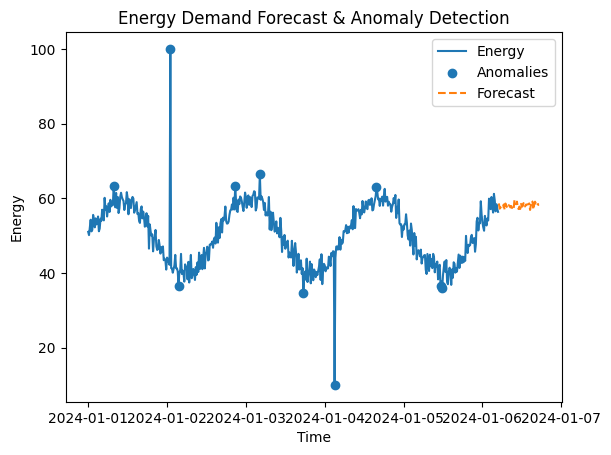

In [6]:
# You are working as a data scientist for a power grid monitoring company.Your goal is to forecast energy demand and also detect abnormal spikes or drops in real-time consumption data collected every 15 minutes. The dataset includes features like timestamp, region, weather conditions, and energy usage.Explain your real-time data science workflow: ● How would you detect anomalies in this streaming data (Isolation Forest / LOF /DBSCAN)? ● Which time series model would you use for short-term forecasting (ARIMA /SARIMA / SARIMAX)? ● How would you validate and monitor the performance over time? ● How would this solution help business decisions or operations?

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -----------------------------
# 1. Create Synthetic Dataset
# -----------------------------
np.random.seed(42)
n = 500

time_index = pd.date_range(start="2024-01-01", periods=n, freq="15T")

# Simulated energy usage with seasonality
energy = 50 + 10*np.sin(np.linspace(0, 20, n)) + np.random.normal(0, 2, n)

# Add anomalies (spikes/drops)
energy[100] = 100
energy[300] = 10

df = pd.DataFrame({"energy": energy}, index=time_index)

# -----------------------------
# 2. Anomaly Detection (Isolation Forest)
# -----------------------------
model_if = IsolationForest(contamination=0.02, random_state=42)
df['anomaly'] = model_if.fit_predict(df[['energy']])

# -----------------------------
# 3. Forecasting (SARIMAX)
# -----------------------------
model_sarimax = SARIMAX(df['energy'], order=(1,1,1), seasonal_order=(1,1,1,96))
results = model_sarimax.fit()

forecast = results.forecast(steps=50)

# -----------------------------
# 4. Visualization
# -----------------------------
plt.figure()

# Plot energy usage
plt.plot(df.index, df['energy'], label="Energy")

# Highlight anomalies
anomalies = df[df['anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['energy'], label="Anomalies")

# Plot forecast
plt.plot(forecast.index, forecast, linestyle='--', label="Forecast")

plt.title("Energy Demand Forecast & Anomaly Detection")
plt.xlabel("Time")
plt.ylabel("Energy")
plt.legend()
plt.show()